
Step size h = 0.01
Eigenvalues: [1.+0.01j 1.-0.01j]
Magnitudes: [1.00005 1.00005]
Solution may not be Entirely Stable ;)

Step size h = 0.02
Eigenvalues: [1.+0.02j 1.-0.02j]
Magnitudes: [1.00019998 1.00019998]
Solution may not be Entirely Stable ;)

Step size h = 0.03
Eigenvalues: [1.+0.03j 1.-0.03j]
Magnitudes: [1.0004499 1.0004499]
Solution may not be Entirely Stable ;)

Step size h = 0.05
Eigenvalues: [1.+0.05j 1.-0.05j]
Magnitudes: [1.00124922 1.00124922]
Solution may not be Entirely Stable ;)

Step size h = 0.1
Eigenvalues: [1.+0.1j 1.-0.1j]
Magnitudes: [1.00498756 1.00498756]
Solution may not be Entirely Stable ;)

Step size h = 0.2
Eigenvalues: [1.+0.2j 1.-0.2j]
Magnitudes: [1.0198039 1.0198039]
Solution may not be Entirely Stable ;)

Step size h = 0.3
Eigenvalues: [1.+0.3j 1.-0.3j]
Magnitudes: [1.04403065 1.04403065]
Solution may not be Entirely Stable ;)

Step size h = 0.5
Eigenvalues: [1.+0.5j 1.-0.5j]
Magnitudes: [1.11803399 1.11803399]
Solution may not be Entirely Stable ;

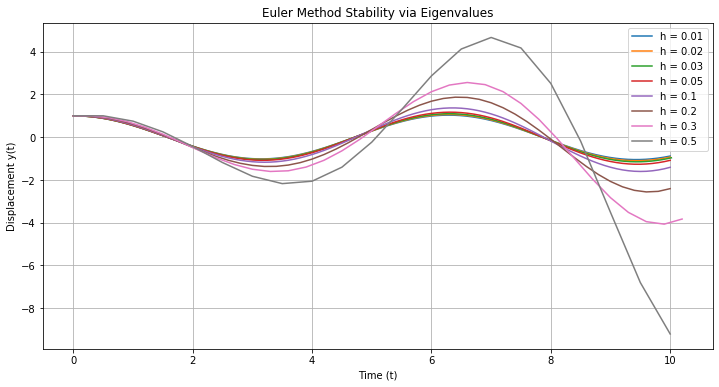

In [9]:
import numpy as np
import matplotlib.pyplot as plt

k = 1.0
h_values = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]
t_start = 0
t_end = 10
y0 = 1.0
v0 = 0.0

A = np.array([[0, 1],
              [-k, 0]])

I = np.eye(2)

def euler_method(h, A, t_start, t_end, y0, v0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))

    y_values[0] = y0
    v_values[0] = v0

    for i in range(1, len(t_values)):
        u_n = np.array([y_values[i-1], v_values[i-1]])
        u_next = u_n + h * A @ u_n   # vector form
        y_values[i], v_values[i] = u_next

    return t_values, y_values

plt.figure(figsize=(12, 6))

for h in h_values:
    # Construct amplification matrix
    M = I + h * A

    # Compute eigenvalues
    eigvals = np.linalg.eigvals(M)
    magnitudes = np.abs(eigvals)

    print(f"\nStep size h = {h}")
    print(f"Eigenvalues: {eigvals}")
    print(f"Magnitudes: {magnitudes}")

    if np.all(magnitudes < 1):
        print("Solution is Stable")
    else:
        print("Solution may not be Entirely Stable ;)")

    t, y = euler_method(h, A, t_start, t_end, y0, v0)

    plt.plot(t, y, label=f"h = {h}")

plt.xlabel("Time (t)")
plt.ylabel("Displacement y(t)")
plt.title("Euler Method Stability via Eigenvalues")
plt.legend()
plt.grid(True)
plt.show()